In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from stargazer.stargazer import Stargazer
import statsmodels.formula.api as smf
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
pd.set_option('display.max_columns', 30)

# Remove people with less than 1k pageviews across all languages

In [2]:
# alive, dead, all
famous_type = 'all'

In [3]:
data = pd.read_csv("../../popularity_data/paper_data/year_month_data_082023.csv",low_memory=False)
data.tail()

,slug,year,ab,ace,ady,af,als,alt,am,ami,an,ang,ann,anp,ar,...,xmf,yi,yo,za,zea,zgh,zh,zh-classical,zh-min-nan,zh-yue,zu,birth,death,occupations,bplace_country
576700,Ḫattušili_III,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2526.0,NaN,NaN,NaN,NaN,-1267.0,-1300.0,POLITICIAN,Iraq
576701,Ḫattušili_III,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.0,...,NaN,NaN,NaN,NaN,NaN,NaN,3309.0,NaN,NaN,NaN,NaN,-1267.0,-1300.0,POLITICIAN,Iraq
576702,Ḫattušili_III,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1546.0,...,NaN,NaN,NaN,NaN,NaN,NaN,3022.0,NaN,NaN,NaN,NaN,-1267.0,-1300.0,POLITICIAN,Iraq
576703,Ḫattušili_III,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2157.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2690.0,NaN,NaN,NaN,NaN,-1267.0,-1300.0,POLITICIAN,Iraq
576704,Ḫattušili_III,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1034.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1812.0,NaN,NaN,NaN,NaN,-1267.0,-1300.0,POLITICIAN,Iraq


In [4]:
ordered_languages = list(data.columns[3:-4])
len(ordered_languages)

336

In [5]:
ordered_languages[0], ordered_languages[-1]

('ace', 'zu')

In [6]:
time_cols = ['year']

In [7]:
aux = data.groupby('slug')['year'].min().reset_index()
aux.columns= ['slug','first_wikipedia_year']
data = data.merge(aux, how='left')
data.head()

,slug,year,ab,ace,ady,af,als,alt,am,ami,an,ang,ann,anp,ar,...,yi,yo,za,zea,zgh,zh,zh-classical,zh-min-nan,zh-yue,zu,birth,death,occupations,bplace_country,first_wikipedia_year
0,"""Weird_Al""_Yankovic",2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,248.0,NaN,NaN,NaN,497.0,...,NaN,284.0,NaN,NaN,NaN,4139.0,NaN,207.0,NaN,NaN,1959.0,NaN,SINGER,United States,2015
1,"""Weird_Al""_Yankovic",2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,695.0,NaN,NaN,NaN,1062.0,...,NaN,491.0,NaN,NaN,NaN,11191.0,NaN,405.0,NaN,NaN,1959.0,NaN,SINGER,United States,2015
2,"""Weird_Al""_Yankovic",2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2973.0,NaN,NaN,NaN,868.0,...,NaN,349.0,NaN,NaN,NaN,6617.0,NaN,355.0,NaN,NaN,1959.0,NaN,SINGER,United States,2015
3,"""Weird_Al""_Yankovic",2018,NaN,NaN,NaN,88.0,NaN,NaN,NaN,NaN,402.0,NaN,NaN,NaN,872.0,...,NaN,441.0,NaN,NaN,NaN,5695.0,NaN,332.0,NaN,NaN,1959.0,NaN,SINGER,United States,2015
4,"""Weird_Al""_Yankovic",2019,NaN,NaN,NaN,485.0,NaN,NaN,NaN,NaN,400.0,NaN,NaN,NaN,967.0,...,NaN,393.0,NaN,NaN,NaN,5330.0,NaN,426.0,NaN,NaN,1959.0,NaN,SINGER,United States,2015


In [8]:
aux['first_wikipedia_year'].value_counts()

2015    57578
2016     1062
2018      379
2017      356
2019       94
2020        2
Name: first_wikipedia_year, dtype: int64

In [9]:
slug_cols = time_cols + ['slug']

In [10]:
del aux

In [11]:
data["Volume"] = data.groupby(by=slug_cols)[ordered_languages].fillna(0).astype(float).sum(axis=1)

In [12]:
data = data[data["Volume"]>=1000].copy()

In [13]:
data = data[data['slug']!='Cleopatra'].copy()

In [14]:
data.loc[data['slug'].str.contains('Bernardo_OHiggins'), 'birth'] = 1778
data.loc[data['slug'].str.contains('Bernardo_OHiggins'), 'death'] = 1842
data.loc[data['slug'].str.contains('Bernardo_OHiggins'), 'occupations'] = 'POLITICIAN'

In [15]:
data.loc[data['bplace_country']=='Frankfurt','bplace_country'] = 'Germany'
data.loc[data['bplace_country']=='German empire','bplace_country'] = 'Germany'
data.loc[data['bplace_country']=='Ancient Rome','bplace_country'] = 'Italy'

data.loc[data['slug'].apply(str).str.contains("Britain"),'bplace_country'] = 'United Kingdom'
data.loc[data['slug']=='Johnny_Unitas', 'occupations'] = 'american football player'
data.loc[data['slug']=='Franklin_D._Roosevelt', 'occupations'] = 'POLITICIAN'
data.loc[(data["slug"].isin(['Bernardo_OHiggins'])),'occupations'] = 'POLITICIAN'

In [16]:
# famous_type
if famous_type == 'alive':
    data = data[(data["birth"]>=1915)]
    data = data[(data["death"].isna())]
    print(famous_type, "Birth>=1915 & death is NaN")
elif famous_type == 'dead':
    data = data[(data["birth"]<2015)]
    data = data[(data["death"]<2015)]
    print(famous_type, "Birth<2015 & Death<2015")
else:
    print(famous_type, "no changes")

all no changes


In [17]:
data['slug'].nunique() # 28253 ; 22691

59255

In [18]:
28253+22691

50944

In [19]:
len(data.loc[data['slug'].str.contains('Donald_Trump')]), len(data.loc[data['slug'].str.contains('Bernardo_OHiggins')])

(20, 10)

# Calculate local 

In [20]:
slug_cols

['year', 'slug']

In [21]:
def get_language(x):
    return ordered_languages[np.argmax(x)]

data["Locality_lang"] = (data.groupby(by=slug_cols)[ordered_languages].transform(max)).apply(lambda x: get_language(x), axis=1)
data.head()

,slug,year,ab,ace,ady,af,als,alt,am,ami,an,ang,ann,anp,ar,...,za,zea,zgh,zh,zh-classical,zh-min-nan,zh-yue,zu,birth,death,occupations,bplace_country,first_wikipedia_year,Volume,Locality_lang
0,"""Weird_Al""_Yankovic",2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,248.0,NaN,NaN,NaN,497.0,...,NaN,NaN,NaN,4139.0,NaN,207.0,NaN,NaN,1959.0,NaN,SINGER,United States,2015,685999.0,en
1,"""Weird_Al""_Yankovic",2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,695.0,NaN,NaN,NaN,1062.0,...,NaN,NaN,NaN,11191.0,NaN,405.0,NaN,NaN,1959.0,NaN,SINGER,United States,2015,1984716.0,en
2,"""Weird_Al""_Yankovic",2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2973.0,NaN,NaN,NaN,868.0,...,NaN,NaN,NaN,6617.0,NaN,355.0,NaN,NaN,1959.0,NaN,SINGER,United States,2015,1753975.0,en
3,"""Weird_Al""_Yankovic",2018,NaN,NaN,NaN,88.0,NaN,NaN,NaN,NaN,402.0,NaN,NaN,NaN,872.0,...,NaN,NaN,NaN,5695.0,NaN,332.0,NaN,NaN,1959.0,NaN,SINGER,United States,2015,1716270.0,en
4,"""Weird_Al""_Yankovic",2019,NaN,NaN,NaN,485.0,NaN,NaN,NaN,NaN,400.0,NaN,NaN,NaN,967.0,...,NaN,NaN,NaN,5330.0,NaN,426.0,NaN,NaN,1959.0,NaN,SINGER,United States,2015,1846256.0,en


In [22]:
local_num = (data.groupby(by=["slug","year"])[ordered_languages].transform(np.max)).max(axis=1).apply(lambda x: np.log(x))

maximum_year = data.groupby(by=["year"])[ordered_languages].max().to_dict()
local_den = data.apply(lambda x: maximum_year[x['Locality_lang']][x['year']], axis=1).apply(lambda x: np.log(x))

data["Local_raw"] = local_num/local_den
data["maximum"] = data[["year","Local_raw"]].groupby(by=["year"]).transform(np.max)
data["minimum"] = data[["year","Local_raw"]].groupby(by=["year"]).transform(np.min)
data["local"] = (data["Local_raw"]-data["minimum"])/(data["maximum"]-data["minimum"])
data.drop(columns=['maximum','minimum'], inplace=True)
data.head()

,slug,year,ab,ace,ady,af,als,alt,am,ami,an,ang,ann,anp,ar,...,zgh,zh,zh-classical,zh-min-nan,zh-yue,zu,birth,death,occupations,bplace_country,first_wikipedia_year,Volume,Locality_lang,Local_raw,local
0,"""Weird_Al""_Yankovic",2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,248.0,NaN,NaN,NaN,497.0,...,NaN,4139.0,NaN,207.0,NaN,NaN,1959.0,NaN,SINGER,United States,2015,685999.0,en,0.786811,0.686553
1,"""Weird_Al""_Yankovic",2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,695.0,NaN,NaN,NaN,1062.0,...,NaN,11191.0,NaN,405.0,NaN,NaN,1959.0,NaN,SINGER,United States,2015,1984716.0,en,0.790601,0.682772
2,"""Weird_Al""_Yankovic",2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2973.0,NaN,NaN,NaN,868.0,...,NaN,6617.0,NaN,355.0,NaN,NaN,1959.0,NaN,SINGER,United States,2015,1753975.0,en,0.825261,0.736842
3,"""Weird_Al""_Yankovic",2018,NaN,NaN,NaN,88.0,NaN,NaN,NaN,NaN,402.0,NaN,NaN,NaN,872.0,...,NaN,5695.0,NaN,332.0,NaN,NaN,1959.0,NaN,SINGER,United States,2015,1716270.0,en,0.821383,0.728824
4,"""Weird_Al""_Yankovic",2019,NaN,NaN,NaN,485.0,NaN,NaN,NaN,NaN,400.0,NaN,NaN,NaN,967.0,...,NaN,5330.0,NaN,426.0,NaN,NaN,1959.0,NaN,SINGER,United States,2015,1846256.0,en,0.804583,0.715257


In [23]:
del maximum_year, local_num, local_den

# Calculate global 

In [24]:
WT = data.groupby(by="year")[ordered_languages].sum().T.sum().reset_index(name='total')
WT = WT.set_index('year').T
WT

year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
total,7.357100e+09,1.645722e+10,1.608721e+10,1.689619e+10,1.750410e+10,1.975004e+10,1.914549e+10,1.932171e+10,1.970480e+10,9.186634e+09


In [25]:
PT_df = data.groupby(by=["year"])[ordered_languages].sum().T.reset_index()
PT_df.rename(columns={'index':'lang'}, inplace=True)
PT_df = PT_df.set_index('lang').fillna(0)
PT_df

year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
lang,,,,,,,,,,
ace,38669.0,76636.0,80178.0,89753.0,113574.0,161674.0,156334.0,219860.0,255753.0,120020.0
ady,0.0,5956.0,8959.0,10265.0,15148.0,17833.0,13866.0,22254.0,25897.0,19528.0
af,754388.0,1795514.0,2007677.0,2325347.0,3331341.0,4113649.0,5647727.0,6411943.0,6232494.0,3129790.0
als,303500.0,714375.0,640782.0,707416.0,809566.0,1122497.0,1963046.0,2112720.0,1722914.0,635700.0
alt,0.0,0.0,0.0,0.0,0.0,0.0,31863.0,62022.0,61353.0,46125.0
...,...,...,...,...,...,...,...,...,...,...
zh,86043688.0,214757457.0,230644494.0,249617030.0,257591167.0,285043531.0,363268129.0,341363623.0,277113094.0,149054789.0
zh-classical,94451.0,190718.0,194084.0,271330.0,256371.0,282301.0,287939.0,385848.0,455298.0,312531.0
zh-min-nan,235489.0,511154.0,623822.0,742402.0,828099.0,1263189.0,1578115.0,1783691.0,1627974.0,836427.0


In [26]:
CT_df = data.set_index(['year','slug'])[ordered_languages].sum(axis=1).reset_index(name='values')
CT_df

,year,slug,values
0,2015,"""Weird_Al""_Yankovic",685999.0
1,2016,"""Weird_Al""_Yankovic",1984716.0
2,2017,"""Weird_Al""_Yankovic",1753975.0
3,2018,"""Weird_Al""_Yankovic",1716270.0
4,2019,"""Weird_Al""_Yankovic",1846256.0
...,...,...,...
564183,2020,Ḫattušili_III,59149.0
564184,2021,Ḫattušili_III,63863.0
564185,2022,Ḫattušili_III,60676.0
564186,2023,Ḫattušili_III,57097.0


In [27]:
cols = ['slug', 'year'] + ordered_languages

In [110]:
slug = "Elinor_Ostrom"

for year in range(2015, 2024):

    therow = each_row[1][ordered_languages].fillna(0)
    denominator_df = (PT_df[year] / WT[year].values[0])
    
    CTrow = CT_df[(CT_df['year']==year)  &  (CT_df['slug']==slug)]['values'].values[0]
    numerator = (therow/CTrow)
    compute_ = [slug,year] + list(((therow/CTrow) / (denominator_df)).fillna(0).values)
    see_ = pd.DataFrame([compute_], columns=list(np.hstack(['slug','year',ordered_languages])))
    see_ = see_.T.T
    aux_ = (see_[ordered_languages]>0).T
    print(year, see_['ca'].values[0])

2015 3.309092175719018
2016 1.3893830146382875
2017 1.3833150655811763
2018 0.9159334663480564
2019 0.7389858243408085
2020 0.7499205232073468
2021 0.7499199137714095
2022 0.790120723437065
2023 0.9406134451873682


In [28]:
RCA = []
for each_row in data[cols].iterrows():
    slug = each_row[1]['slug']
    year = each_row[1]['year']
    
    therow = each_row[1][ordered_languages].fillna(0)
    denominator_df = (PT_df[year] / WT[year].values[0])
    
    CTrow = CT_df[(CT_df['year']==year)  &  (CT_df['slug']==slug)]['values'].values[0]
    numerator = (therow/CTrow)
    compute_ = [slug,year] + list(((therow/CTrow) / (denominator_df)).fillna(0).values)
    RCA.append(compute_)

df = pd.DataFrame(RCA)
df.columns = list(np.hstack(['slug','year',ordered_languages]))
n_languages = df.set_index(['slug','year']).apply(lambda x: x>1, axis=1).sum(axis=1).reset_index(name='n_languages')
n_languages

,slug,year,n_languages
0,"""Weird_Al""_Yankovic",2015,32
1,"""Weird_Al""_Yankovic",2016,31
2,"""Weird_Al""_Yankovic",2017,35
3,"""Weird_Al""_Yankovic",2018,36
4,"""Weird_Al""_Yankovic",2019,38
...,...,...,...
564183,Ḫattušili_III,2020,28
564184,Ḫattušili_III,2021,29
564185,Ḫattušili_III,2022,29
564186,Ḫattušili_III,2023,33


In [29]:
def normalize(X):
    scaler = MinMaxScaler()
    scaler.fit(X)
    return scaler.transform(X)

# % RCA
n_languages['Global_raw'] = n_languages['n_languages']/len(ordered_languages)

n_languages["max"] = n_languages[["year","Global_raw"]].groupby(by=["year"]).transform(np.max)
n_languages["min"] = n_languages[["year","Global_raw"]].groupby(by=["year"]).transform(np.min)
n_languages['global'] = (n_languages['Global_raw']-n_languages['min'])/(n_languages['max']-n_languages['min'])
n_languages.drop(columns=['max','min'], inplace=True)

In [30]:
n_languages[(n_languages['year']==2022) & (n_languages['slug']=="Napoleon")]

,slug,year,n_languages,Global_raw,global
402365,Napoleon,2022,175,0.520833,0.852941


In [31]:
n_languages[(n_languages['year']==2022) & (n_languages['slug']=="Bernardo_OHiggins")]

,slug,year,n_languages,Global_raw,global
82180,Bernardo_OHiggins,2022,29,0.08631,0.137255


In [32]:
n_languages[(n_languages['year']==2022) & (n_languages['slug']=="Johnny_Unitas")]

,slug,year,n_languages,Global_raw,global
297826,Johnny_Unitas,2022,11,0.032738,0.04902


In [38]:
n_languages[(n_languages['year']==2022) & (n_languages['slug']=="Elinor_Ostrom")]

,slug,year,n_languages,Global_raw,global
181776,Elinor_Ostrom,2022,68,0.202381,0.328431


In [33]:
n_languages[(n_languages['year']==2022) & (n_languages['slug']=="Audie_Murphy")]

,slug,year,n_languages,Global_raw,global
70236,Audie_Murphy,2022,8,0.02381,0.034314


In [34]:
n_languages['year'] = n_languages['year'].astype(int)
data['year'] = data['year'].astype(int)

In [35]:
len(n_languages), len(data)

(564188, 564188)

In [36]:
n_languages.head()

,slug,year,n_languages,Global_raw,global
0,"""Weird_Al""_Yankovic",2015,32,0.095238,0.174157
1,"""Weird_Al""_Yankovic",2016,31,0.092262,0.165746
2,"""Weird_Al""_Yankovic",2017,35,0.104167,0.177083
3,"""Weird_Al""_Yankovic",2018,36,0.107143,0.169903
4,"""Weird_Al""_Yankovic",2019,38,0.113095,0.172897


In [37]:
"finished"

'finished'

In [93]:
data = n_languages.merge(data, on=['slug','year'], how='left').drop_duplicates()

In [ ]:
n_languages.to_csv("data/n_languages_checklanguages.csv", index=False)
data.to_csv("data/data_checklanguages.csv", index=False)

In [94]:
print(data[data['Locality_lang']=='ca']['slug'].unique())

['Alyn_Smith' 'Andrej_Hunko' 'Annie_S._D._Maunder'
 'Antoni_Maria_Alcover_i_Sureda' 'Artur_Mas' 'Ausiàs_March'
 'Bart_De_Wever' 'Bernard_Desclot' 'Can_Dündar' 'Carles_Puigdemont'
 'Carme_Forcadell' 'Caterina_Albert' 'Caterina_Mieras'
 'Cebrià_de_Montoliu' 'Cerverí_de_Girona' 'Clara_Ponsatí'
 'Enric_Prat_de_la_Riba' 'Ernest_Maragall'
 'Francesca_Bonnemaison_i_Farriols' 'Isabel-Clara_Simó' 'Jacint_Verdaguer'
 'Jaume_Doménech' 'Joan_Alcover' 'Joan_Botam' 'Joan_Coromines'
 'Joan_Maragall' 'Jordi_Cuixart' 'José_María_Ventura_Casas'
 'Juan_José_Ibarretxe' 'Juan_Manuel_Moreno' 'Katja_Dörner'
 'Kenny_MacAskill' 'Lluís_Companys' 'Lluís_Llach' 'Lola_Anglada'
 'Marta_Rovira' 'Milan_Kučan' 'Miquel-Lluís_Muntané'
 'Muriel_Casals_i_Couturier' 'Màrius_Serra' 'Ona_Carbonell'
 'Oriol_Junqueras' 'Pablo_Casado' 'Pedro_Sánchez' 'Pere_Tarrés_i_Claret'
 'Quim_Monzó' 'Quim_Torra' 'Rafael_Casanova' 'Robert_Gerhard'
 'Rosa_Sensat' 'Salvador_Puig_Antich' 'Selahattin_Demirtaş'
 'Steingrímur_J._Sigfússon' 'Vicenç

In [96]:
data[data['slug']=='Elinor_Ostrom']

,slug,year,n_languages,Global_raw,global,ab,ace,ady,af,als,alt,am,ami,an,ang,...,zgh,zh,zh-classical,zh-min-nan,zh-yue,zu,birth,death,occupations,bplace_country,first_wikipedia_year,Volume,Locality_lang,Local_raw,local
181769,Elinor_Ostrom,2015,48,0.142857,0.264045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2042.0,NaN,NaN,168.0,NaN,1933.0,2012.0,ECONOMIST,United States,2015,121908.0,en,0.647313,0.481453
181770,Elinor_Ostrom,2016,51,0.151786,0.276243,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,4667.0,NaN,NaN,397.0,NaN,1933.0,2012.0,ECONOMIST,United States,2015,276551.0,en,0.647417,0.465856
181771,Elinor_Ostrom,2017,54,0.160714,0.276042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,6161.0,NaN,NaN,413.0,NaN,1933.0,2012.0,ECONOMIST,United States,2015,262563.0,en,0.675504,0.511307
181772,Elinor_Ostrom,2018,56,0.166667,0.266990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,6080.0,NaN,NaN,305.0,NaN,1933.0,2012.0,ECONOMIST,United States,2015,299168.0,en,0.678594,0.512042
181773,Elinor_Ostrom,2019,56,0.166667,0.257009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,6256.0,NaN,NaN,474.0,NaN,1933.0,2012.0,ECONOMIST,United States,2015,328675.0,en,0.672253,0.522438
181774,Elinor_Ostrom,2020,61,0.181548,0.298507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,6418.0,NaN,NaN,539.0,NaN,1933.0,2012.0,ECONOMIST,United States,2015,344835.0,en,0.621759,0.457193
181775,Elinor_Ostrom,2021,65,0.193452,0.320000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,7903.0,NaN,NaN,609.0,NaN,1933.0,2012.0,ECONOMIST,United States,2015,339466.0,en,0.622717,0.449698
181776,Elinor_Ostrom,2022,68,0.202381,0.328431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,7319.0,NaN,NaN,910.0,NaN,1933.0,2012.0,ECONOMIST,United States,2015,321652.0,en,0.633427,0.467389
181777,Elinor_Ostrom,2023,67,0.199405,0.265060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,6099.0,NaN,NaN,782.0,NaN,1933.0,2012.0,ECONOMIST,United States,2015,321768.0,en,0.664132,0.512501
181778,Elinor_Ostrom,2024,68,0.202381,0.231834,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,4072.0,NaN,NaN,723.0,NaN,1933.0,2012.0,ECONOMIST,United States,2015,184793.0,en,0.655349,0.509005


In [124]:
data['slug'].nunique()

23673

# Plot Local and Global Collective Memory

In [125]:
data.drop(columns=ordered_languages, inplace=True)

In [126]:
from datetime import datetime
daycollec = datetime.today().strftime('%Y%m%d')
daycollec

'20241203'

In [127]:
"data/%s_clean_localglobal_%s.csv"%(daycollec, famous_type)

'data/20241203_clean_localglobal_dead.csv'

In [128]:
data.to_csv("data/%s_clean_localglobal_%s.csv"%(daycollec, famous_type), index=False)
"finished..."

'finished...'

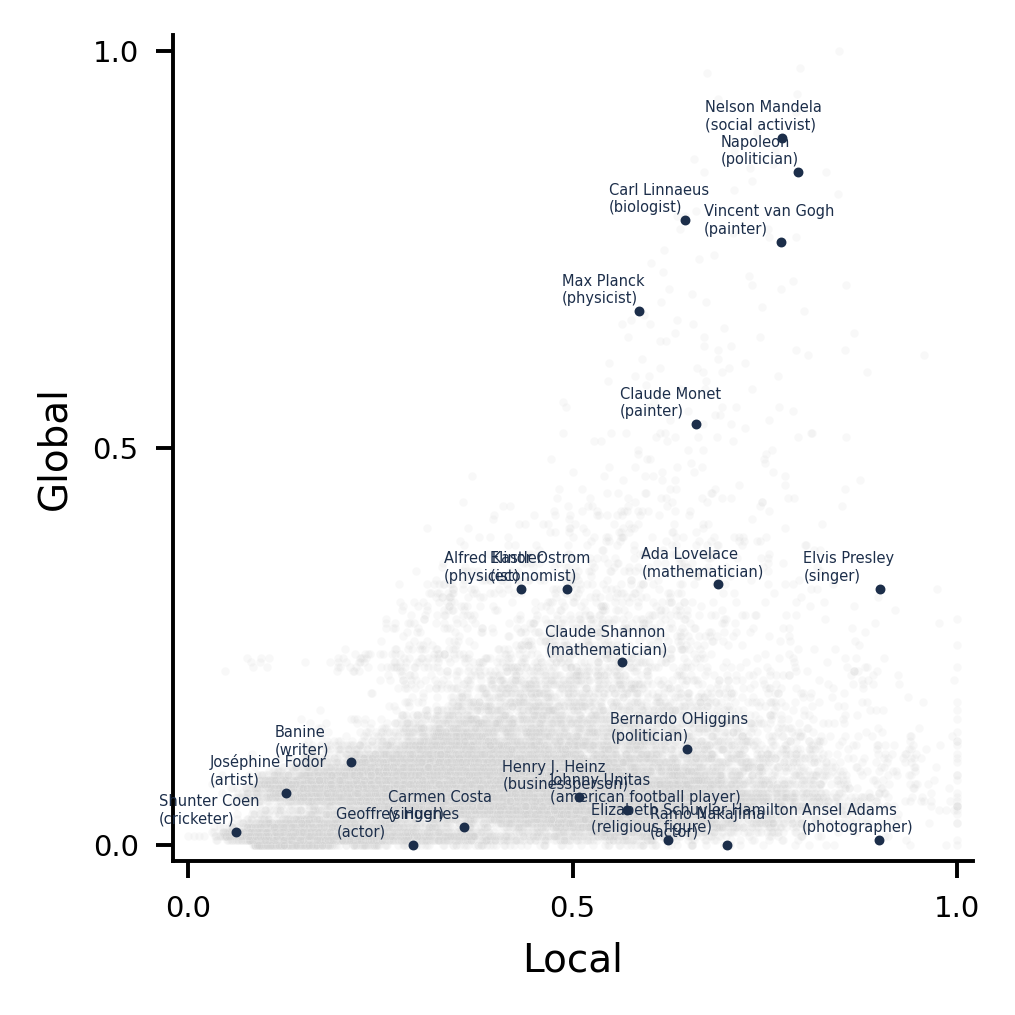

In [129]:
fig, ax = plt.subplots(figsize=(3,3),dpi=350)
lang2 = 'global'
lang1 = 'local'
show = True
year = 2022
data.loc[(data["slug"].isin(['Bernardo_OHiggins'])),'occupations'] = 'POLITICIAN'

aux_2 = data[(data["year"]==year) & (data[lang1]<=1) & (data[lang2]<=1)][['year',lang2,\
                                lang1,'occupations','slug']].drop_duplicates()\
                            .groupby(['year','slug'])[[lang2,
                                lang1]].mean()
# aux_2[lang1] = np.square(-np.log(aux_2[lang1]*500))
# aux_2[lang2] = np.square(-np.log(aux_2[lang2]*500))
sns.scatterplot(data=aux_2, x=lang1, y=lang2, s=3, alpha=0.15,
                color='lightgrey',
                markers=['o','s','>','^'], 
                legend=False, ax=ax) 

ax.set_xlabel("Local")
ax.set_ylabel("Global")

# ax.axhline(aux_2[lang2].median(), linestyle='dotted', alpha=0.5, color='grey')
# ax.axvline(aux_2[lang1].median(), linestyle='dotted', alpha=0.5, color='grey')

# ,"Viola_Davis","Katie_Holmes","Ching_Siu-tung","Maria_Dulce"\
                                 # ,"David_Schwimmer","Noah_Bean", "Mía_Maestro", "Tyler_Perry"

# "Dominique_Deruddere","Joseph_Bové","Piotr_Cugowski","David_Strauss","Maria_Helena_Andrés","Bruno_Bettinelli",\
#                                  "Veronika_Dudarova","Shukurbek_Beyshenaliev","Shakira","Konstanty_Kalinowski",\
#                                  "Étienne_Gailly","Joséphine_Fodor","Shunter_Coen",'Basshunter',
# "Margaret_Thatcher","Britney_Spears","Paul_Simon","Johnny_Unitas","Elinor_Ostrom",
# 'Donald_Trump','David_Woodard','The_Weeknd','Corbin_Bleu','Catherine_Holman','Charlotte_Rampling'
including_ = ['Carmen_Costa','Ansel_Adams','Ramo_Nakajima','Aleksei_Yuryevich_German	','Elizabeth_Schuyler_Hamilton','Geoffrey_Hughes','',\
              'George_Ball','Elvis_Presley','','Henry_J._Heinz','Ada_Lovelace','Claude_Monet',\
              'Max_Planck','Carl_Linnaeus','','Alfred_Kastler','Vincent_van_Gogh','Banine'\
              ,'Napoleon','Bernardo_OHiggins','Herta_Müller','Aaron_Hernandez','Cristiano_Ronaldo','Claude_Shannon',\
              'Galla_Placidia',"Paul_Simon","Joséphine_Fodor","Shunter_Coen",'Nelson_Mandela',\
              'Misako_Tanaka',"Johnny_Unitas","Elinor_Ostrom",'Donald_Trump','David_Woodard','',\
              'Catherine_Holman','Charlotte_Rampling','']

aux_2 = data[(data["slug"].isin(including_)) &\
             (data['year']==year) ][['year',lang2,lang1,'slug','occupations']].groupby(['year','slug','occupations'])[[lang2,lang1]].mean().reset_index()
# aux_2[lang1] = np.square(-np.log(aux_2[lang1]*500))
# aux_2[lang2] = np.square(-np.log(aux_2[lang2]*500))

sns.scatterplot(data=aux_2, x=lang1, y=lang2, s=3, 
#                 hue='K',
                color='#1c2e4a',edgecolor='#1c2e4a',linewidth=0.3,
#                 style='occupation',
                markers=['o','s','>','^'], 
                legend=False, ax=ax) 

if show == True:
    for point in aux_2.iterrows():
        t = ax.text(point[1][lang1]-0.10, point[1][lang2]+0.01, str(point[1]['slug']).replace("_(footballer)","").replace("_"," ")+"\n(%s)"%point[1]['occupations'].lower(),\
                    fontsize=3, color='#1c2e4a', alpha=1, fontweight='normal')
        # t.set_bbox(dict(facecolor='white', alpha=0.5, edgecolor='white'))


ax.set_ylim(-0.02,1.02)
ax.set_xlim(-0.02,1.02)

ax.set_xticks([0, 0.5, 1.0])
ax.set_yticks([0, 0.5, 1.0])
ax.spines[['right', 'top']].set_visible(False)


ax.tick_params(axis='both', which='major', labelsize=6)
ax.tick_params(axis='both', which='minor', labelsize=6)

ax.set_xlabel("Local",fontsize=8)
ax.set_ylabel("Global",fontsize=8)

plt.tight_layout()

fig.savefig("FigurePeople_2022.svg")
# fig.savefig("Figure.svg")